# Thermal utilities: mass flow, temperature quality, exergy, and hydraulics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/equinor/neqsim/blob/master/examples/notebooks/energy_networks/03_thermal_utilities_and_hydraulics.ipynb)

This notebook converts utility duty to real mass flow, checks temperature-grade feasibility, reports exergy, and screens a utility header for pressure drop and pump power.

**Release requirement:** NeqSim 3.17.0 or later.\n\n**Implementation history:** PRs #2610, #2612, and #2616.
**Validated environment:** stored outputs use NeqSim 3.17.0, Python 3.12.13, and OpenJDK 17.0.19.


## 1. Setup

In [1]:
import importlib.metadata
import importlib.util
import subprocess
import sys

if (
    importlib.util.find_spec("google") is not None
    and importlib.util.find_spec("google.colab") is not None
):
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "neqsim==3.17.0",
        ],
        check=True,
    )

from neqsim import jneqsim
from jpype import JClass

neqsim_version = importlib.metadata.version("neqsim")
if neqsim_version != "3.17.0":
    raise RuntimeError(
        "This stored-output example was validated with NeqSim 3.17.0; " f"found {neqsim_version}."
    )
print(f"NeqSim {neqsim_version} loaded from the public Python package")


NeqSim 3.17.0 loaded from the public Python package


In [2]:
UtilityEnergyBus = jneqsim.process.equipment.energy.UtilityEnergyBus
ThermalUtilityState = jneqsim.process.equipment.energy.ThermalUtilityState
ThermalUtilityQualityAnalysis = jneqsim.process.equipment.energy.ThermalUtilityQualityAnalysis
ThermalUtilityHydraulicModel = jneqsim.process.equipment.energy.ThermalUtilityHydraulicModel
UtilityLevel = jneqsim.process.equipment.stream.UtilityLevel


## 2. LP-steam duty and mass flow

In [3]:
steam_supply = ThermalUtilityState(425.0, 4.0e5, 2.8e6)
condensate_return = ThermalUtilityState(383.0, 4.0e5, 0.6e6)
steam = UtilityEnergyBus(
    "LP steam", UtilityLevel.LOW_PRESSURE_STEAM, steam_supply, condensate_return
)

duties_MW = [1, 2, 4, 6, 8, 10]
steam_rows = []
for duty in duties_MW:
    flow = steam.getMassFlowForDuty(duty, "MW", "kg/sec")
    exergy = ThermalUtilityQualityAnalysis.getExergyRateForDuty(steam, duty * 1e6, 298.15)
    steam_rows.append({"duty_MW": duty, "steam_kg_s": flow, "exergy_MW": exergy / 1e6})


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

steam_df = pd.DataFrame(steam_rows)
steam_df


Out[4]: 
   duty_MW  steam_kg_s  exergy_MW
0        1    0.454545   0.261339
1        2    0.909091   0.522678
2        4    1.818182   1.045357
3        6    2.727273   1.568035
4        8    3.636364   2.090714
5       10    4.545455   2.613392


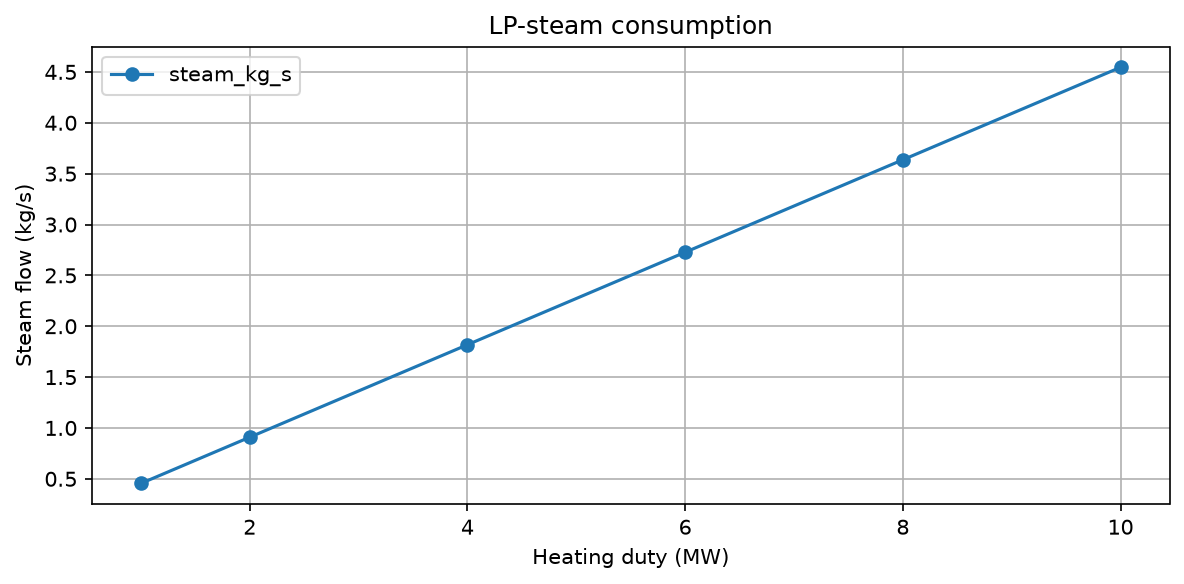

In [5]:
ax = steam_df.plot(x="duty_MW", y="steam_kg_s", marker="o", figsize=(8, 4))
ax.set_xlabel("Heating duty (MW)")
ax.set_ylabel("Steam flow (kg/s)")
ax.set_title("LP-steam consumption")
ax.grid()
plt.tight_layout()
plt.show()


**Interpretation.** The steam requirement is governed by the supply-to-return enthalpy drop, not merely by the utility label.

## 3. Temperature-grade feasibility

In [6]:
process_temperatures = list(range(330, 431, 10))
feasibility = []
for process_T in process_temperatures:
    feasible = ThermalUtilityQualityAnalysis.canServeProcessTemperature(steam, process_T, 10.0)
    feasibility.append({"process_temperature_K": process_T, "feasible": int(feasible)})
feasibility_df = pd.DataFrame(feasibility)
feasibility_df


Out[6]: 
    process_temperature_K  feasible
0                     330         1
1                     340         1
2                     350         1
3                     360         1
4                     370         1
5                     380         1
6                     390         1
7                     400         1
8                     410         1
9                     420         0
10                    430         0


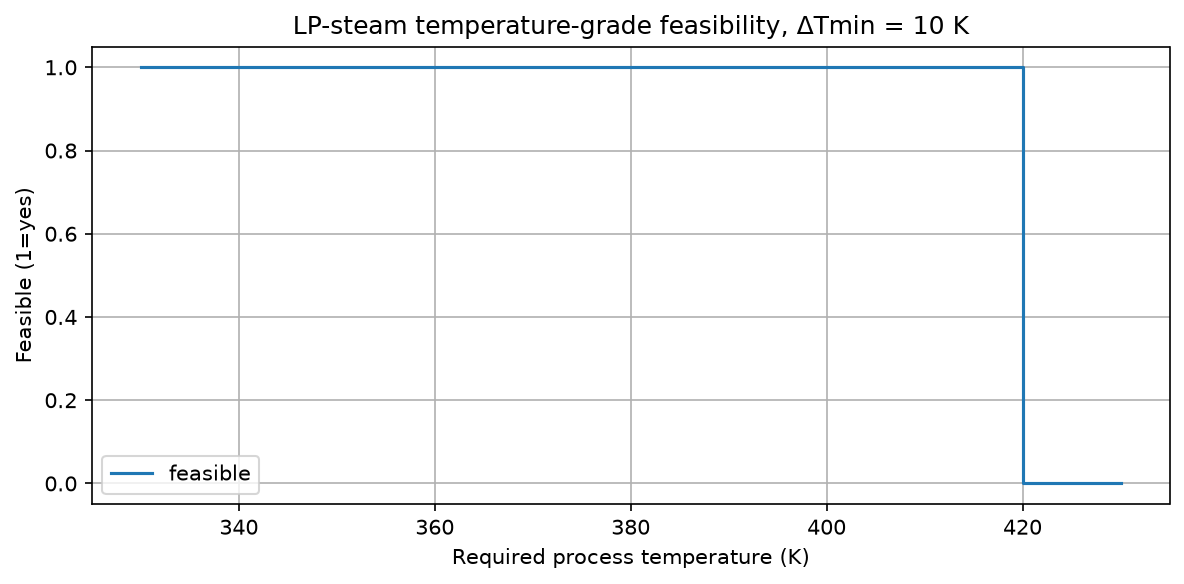

In [7]:
ax = feasibility_df.plot(
    x="process_temperature_K", y="feasible", drawstyle="steps-post", figsize=(8, 4)
)
ax.set_xlabel("Required process temperature (K)")
ax.set_ylabel("Feasible (1=yes)")
ax.set_title("LP-steam temperature-grade feasibility, ΔTmin = 10 K")
ax.set_ylim(-0.05, 1.05)
ax.grid()
plt.tight_layout()
plt.show()


**Interpretation.** Available MW cannot compensate for insufficient temperature grade. Infeasible heat allocations should be rejected before process convergence.

## 4. Cooling-water header hydraulics

In [8]:
cooling_supply = ThermalUtilityState(293.15, 3.0e5, 84.0e3)
cooling_return = ThermalUtilityState(313.15, 2.5e5, 168.0e3)
cooling = UtilityEnergyBus(
    "cooling water", UtilityLevel.COOLING_WATER, cooling_supply, cooling_return
)

header = ThermalUtilityHydraulicModel()
header.setGeometry(500.0, 0.35, 4.5e-5)
header.setFluidProperties(998.0, 1.0e-3)
header.setLocalLossCoefficient(12.0)
header.setPumpEfficiency(0.78)

hyd_rows = []
for duty in [2, 4, 6, 8, 10]:
    mass_flow = cooling.getMassFlowForDuty(duty, "MW", "kg/sec")
    hyd_rows.append(
        {
            "duty_MW": duty,
            "mass_flow_kg_s": mass_flow,
            "velocity_m_s": header.getVelocity(mass_flow),
            "pressure_drop_bar": header.getPressureDrop(mass_flow) / 1e5,
            "pump_power_kW": header.getPumpPower(mass_flow) / 1e3,
        }
    )
hyd_df = pd.DataFrame(hyd_rows)
hyd_df


Out[8]: 
   duty_MW  mass_flow_kg_s  velocity_m_s  pressure_drop_bar  pump_power_kW
0        2       23.809524      0.247967           0.011965       0.036595
1        4       47.619048      0.495934           0.044105       0.269798
2        6       71.428571      0.743902           0.095384       0.875232
3        8       95.238095      0.991869           0.165489       2.024676
4       10      119.047619      1.239836           0.254271       3.888587


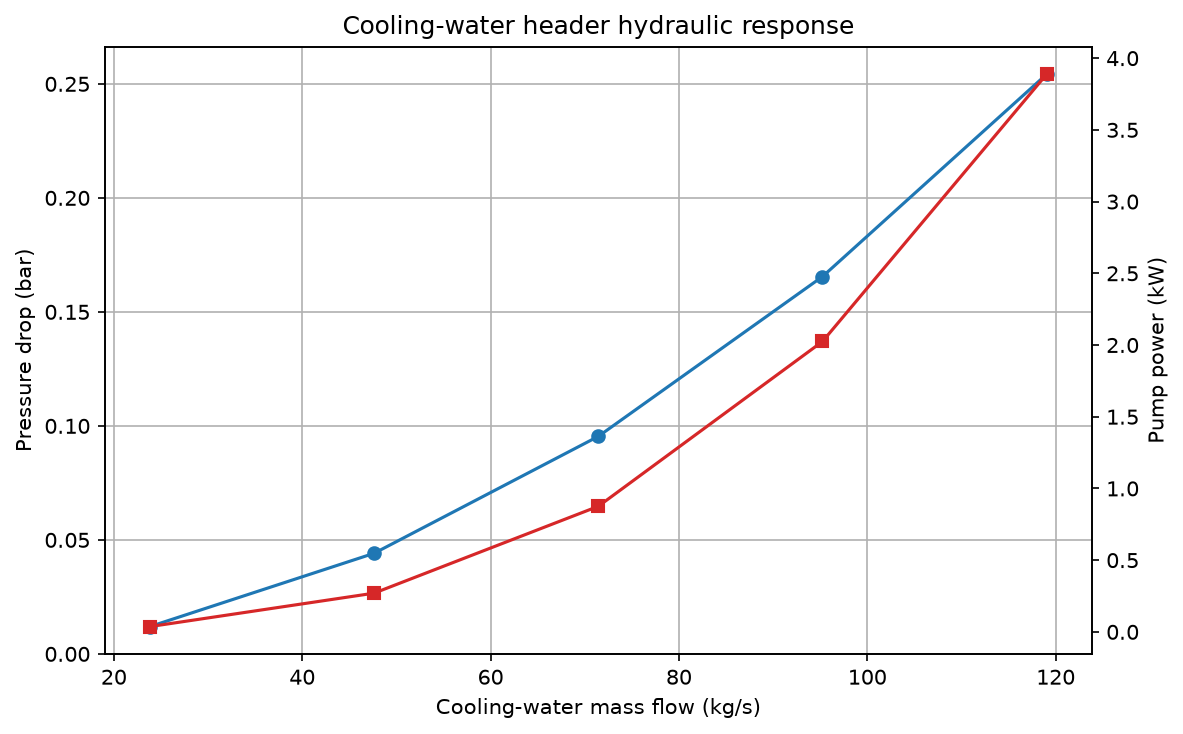

In [9]:
ax = hyd_df.plot(
    x="mass_flow_kg_s",
    y="pressure_drop_bar",
    color="tab:blue",
    marker="o",
    figsize=(8, 5),
    legend=False,
)
hyd_df.plot(
    x="mass_flow_kg_s",
    y="pump_power_kW",
    color="tab:red",
    marker="s",
    secondary_y=True,
    ax=ax,
    legend=False,
)
ax.set_xlabel("Cooling-water mass flow (kg/s)")
ax.set_ylabel("Pressure drop (bar)")
ax.right_ax.set_ylabel("Pump power (kW)")
ax.set_title("Cooling-water header hydraulic response")
ax.grid()
plt.tight_layout()
plt.show()


**Interpretation.** Pressure drop rises approximately with flow squared in turbulent service. Utility duty therefore creates a nonlinear pumping and capacity penalty.

## Validation checks

The assertions below lock the engineering balances and benchmark values used in the interpretation.


In [10]:
expected_steam_flow = steam_df["duty_MW"] * 1e6 / (2.8e6 - 0.6e6)
assert (steam_df["steam_kg_s"] - expected_steam_flow).abs().max() < 1e-12
assert feasibility_df.loc[feasibility_df["process_temperature_K"] <= 410, "feasible"].eq(1).all()
assert feasibility_df.loc[feasibility_df["process_temperature_K"] >= 420, "feasible"].eq(0).all()
assert hyd_df["pressure_drop_bar"].is_monotonic_increasing
assert hyd_df["pump_power_kW"].is_monotonic_increasing

validation = pd.Series(
    {
        "maximum steam-flow residual (kg/s)": (steam_df["steam_kg_s"] - expected_steam_flow)
        .abs()
        .max(),
        "maximum process temperature served (K)": feasibility_df.loc[
            feasibility_df["feasible"].eq(1),
            "process_temperature_K",
        ].max(),
        "maximum header pressure drop (bar)": hyd_df["pressure_drop_bar"].max(),
    }
)
validation


Out[10]: 
maximum steam-flow residual (kg/s)          0.000000
maximum process temperature served (K)    410.000000
maximum header pressure drop (bar)          0.254271
dtype: float64


## Summary

This workflow connects four layers:

1. thermal duty;
2. utility mass flow from enthalpy;
3. temperature-quality and exergy screening;
4. header pressure drop and pump power.

Detailed branched-network hydraulics and compressible steam flow remain specialist calculations.